<h1>Frequency Domain Steganography - Extract</h1>

### Necessary Imports & Declarations & Load the Stego Image

In [2]:
from PIL import Image
import numpy as np
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt


from deepgaze.saliency_map import FasaSaliencyMapping

def load_stego_image(path, size=(224, 224)):
    """
    Load the stego image, resize to expected size (224x224), and convert to uint8.
    """
    img = Image.open(path).convert("RGB")
    img = img.resize(size)
    img_np = np.array(img)
    return img_np  # uint8 image

# Example

stego_img_path = "image_outputs/stegos/ILSVRC2012_val_00005006_stego_80bits.jpeg"  # Replace with actual filename
titles = [os.path.basename(stego_img_path)]  # Just the file name for display


if not os.path.exists(stego_img_path):
    print(f"File not found: {stego_img_path}")
    # Provide a fallback mechanism or prompt the user for a valid path
if os.path.exists(stego_img_path):
    stego_img = load_stego_image(stego_img_path)
else:
    raise FileNotFoundError(f"File still not found: {stego_img_path}")


### DeepGaze 

Processing image 1: shape (224, 224, 3), min 0, max 255


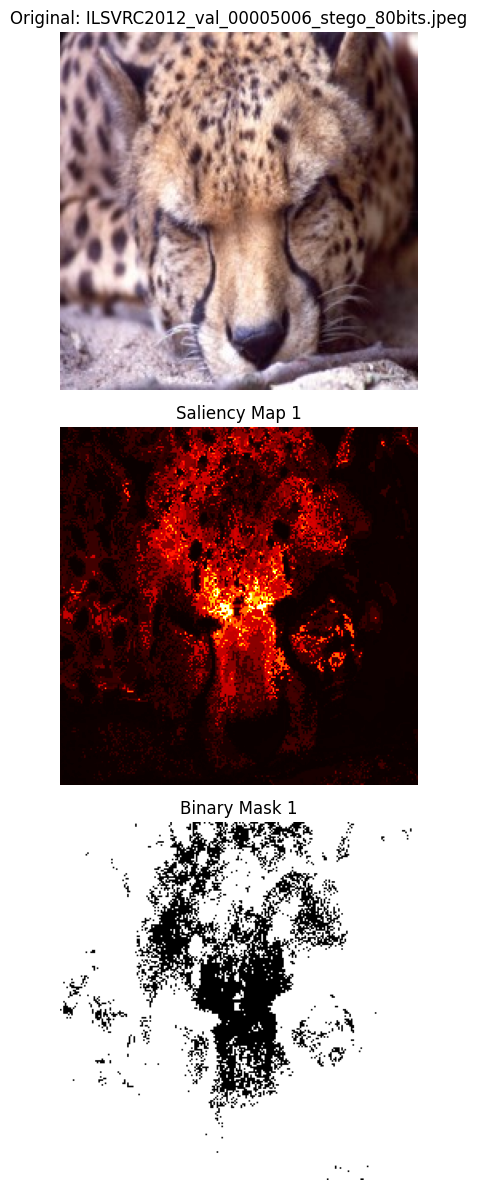

In [4]:
from skimage.filters import threshold_otsu

def gen_saliency_maps(images):
    saliency_maps = []
    for idx, img in enumerate(images):
        # Instantiate a new saliency model for each image (avoids caching/state issues)
        saliency = FasaSaliencyMapping(image_h=224, image_w=224)
        # Convert normalized image (0–1) to uint8 (0–255)
        image_uint8 = (img * 255).astype(np.uint8)
        # (Image is already 224×224)
        print(f"Processing image {idx+1}: shape {image_uint8.shape}, min {image_uint8.min()}, max {image_uint8.max()}")
        sal_map = saliency.returnMask(image_uint8, tot_bins=8, format='RGB')
        saliency_maps.append(sal_map)
    return np.array(saliency_maps)

# Define sample_images using stego_img
sample_images = [stego_img]

# Generate saliency maps for our sample images
saliency_maps = gen_saliency_maps(sample_images)

# For each saliency map, create a binary mask using Otsu's thresholding and display the results.
binary_masks = []
fig, axes = plt.subplots(3, len(sample_images), figsize=(len(sample_images)*4, 12))
for i, (img, sal_map) in enumerate(zip(sample_images, saliency_maps)):
    # Normalize saliency map to [0,255] for visualization
    sal_map_norm = cv2.normalize(sal_map, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')
    thresh_val = threshold_otsu(sal_map_norm)
    binary_mask = (sal_map_norm < thresh_val).astype(np.uint8) * 255
    binary_masks.append(binary_mask)
    
    # Row 0: Original image (resized)
    axes[0].imshow(img)
    axes[0].set_title(f"Original: {titles[i]}")
    axes[0].axis('off')
    # Row 1: Saliency Map
    axes[1].imshow(sal_map_norm, cmap='hot')
    axes[1].set_title(f"Saliency Map {i+1}")
    axes[1].axis('off')
    # Row 2: Binary Mask
    axes[2].imshow(binary_mask, cmap='gray')
    axes[2].set_title(f"Binary Mask {i+1}")
    axes[2].axis('off')
plt.tight_layout()
plt.show()

### Gnereate the block mask

In [5]:
def compute_block_mask(saliency_map, block_size=16, threshold=0.05):
    """
    Compute a binary mask indicating which blocks are good for embedding
    based on average saliency per block.

    Args:
        saliency_map (numpy array): Grayscale saliency map (HxW), normalized [0,1]
        block_size (int): Block size, default 16
        threshold (float): Saliency threshold

    Returns:
        mask (numpy array): Binary mask (h_blocks x w_blocks), 1=good for embedding, 0=skip
    """
    h, w = saliency_map.shape
    h_blocks = h // block_size
    w_blocks = w // block_size

    mask = np.zeros((h_blocks, w_blocks), dtype=np.uint8)

    for i in range(h_blocks):
        for j in range(w_blocks):
            y_start = i * block_size
            x_start = j * block_size
            block = saliency_map[y_start:y_start + block_size, x_start:x_start + block_size]
            avg_saliency = np.mean(block)

            if avg_saliency < threshold:
                mask[i, j] = 1  # Good block for embedding

    return mask


### Overlay the Mask on the Image

In [6]:
def overlay_blocks_on_image(image, block_mask, block_size=16):
    """
    Overlay green/red rectangles on the original image based on the block mask.

    Args:
        image (numpy array): Original RGB image (HxWx3), uint8
        block_mask (numpy array): Binary block mask (h_blocks x w_blocks)
        block_size (int): Block size, default 16

    Returns:
        overlay_img (numpy array): Image with green/red block overlays
    """
    overlay_img = image.copy()
    h_blocks, w_blocks = block_mask.shape

    for i in range(h_blocks):
        for j in range(w_blocks):
            y_start = i * block_size
            x_start = j * block_size

            if block_mask[i, j] == 1:
                color = (0, 255, 0)  # Green for good block
            else:
                color = (255, 0, 0)  # Red for skip block

            # Draw rectangle
            cv2.rectangle(
                overlay_img,
                (x_start, y_start),
                (x_start + block_size - 1, y_start + block_size - 1),
                color,
                1
            )

    return overlay_img


### Display Saliency Maps and Block Overlays

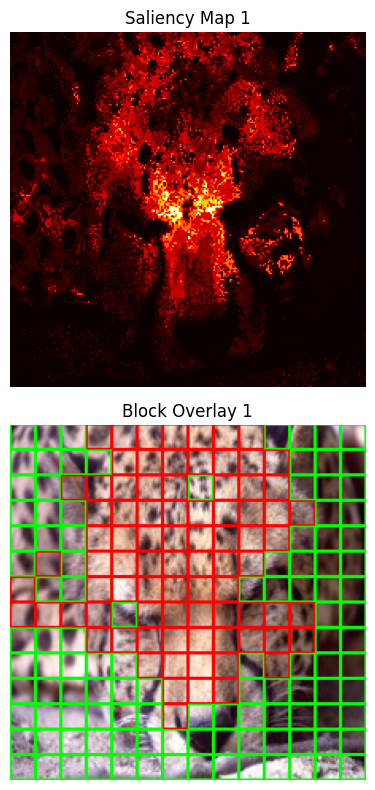

In [ ]:
import matplotlib.pyplot as plt

def display_saliency_and_overlay(saliency_maps, overlay_images, titles=None):
    """
    Display saliency maps and overlay images in two rows:
    - Row 0: Saliency maps (hot colormap)
    - Row 1: Overlay images with green/red blocks

    Args:
        saliency_maps (list): List of saliency maps (HxW), normalized [0,1] or [0,255]
        overlay_images (list): List of overlay images (HxWx3), uint8
        titles (list): Optional list of titles for each image
    """
    num_images = len(saliency_maps)
    fig, axes = plt.subplots(2, num_images, figsize=(num_images * 4, 8))
    axes = axes.flatten()  # Flatten the axes array to make it 1-dimensional

    for i in range(num_images):
        sal_map = saliency_maps[i]
        overlay_img = overlay_images[i]

        # Normalize saliency map for display
        if sal_map.max() <= 1.0:
            sal_map_vis = (sal_map * 255).astype(np.uint8)
        else:
            sal_map_vis = sal_map.astype(np.uint8)

        # Saliency map
        axes[i].imshow(sal_map_vis, cmap='hot')
        axes[i].set_title(f"Saliency Map {i+1}" if not titles else titles[i])
        axes[i].axis('off')

        # Overlay image
        axes[num_images + i].imshow(overlay_img)
        axes[num_images + i].set_title(f"Block Overlay {i+1}" if not titles else titles[i])
        axes[num_images + i].axis('off')

    plt.tight_layout()
    plt.show()


# Parameters
block_size = 8
threshold = 0.05

# Containers for masks and overlay images
block_masks = []
overlay_images = []

# Process each image and saliency map
for img, sal_map in zip(sample_images, saliency_maps):
    # Ensure image is uint8
    img_uint8 = (img * 255).astype(np.uint8) if img.max() <= 1.0 else img

    # Normalize saliency map if necessary
    sal_map_norm = sal_map / 255.0 if sal_map.max() > 1.0 else sal_map

    # Step 1: Compute block mask
    block_mask = compute_block_mask(sal_map_norm, block_size, threshold)
    block_masks.append(block_mask)

    # Step 2: Overlay block mask on image
    overlay_img = overlay_blocks_on_image(img_uint8, block_mask, block_size)
    overlay_images.append(overlay_img)

# Step 3: Display results
display_saliency_and_overlay(saliency_maps, overlay_images)

### Step 2: Split Stego Image into DCT Blocks

In [ ]:
def split_into_dct_blocks(image_uint8, block_size=16):
    """
    Same logic you used for embedding. Converts image to 16x16 blocks and runs DCT on each subblock.
    """
    h, w, _ = image_uint8.shape
    h_blocks = h // block_size
    w_blocks = w // block_size

    dct_blocks_info = []

    for i in range(h_blocks):
        for j in range(w_blocks):
            y_start = i * block_size
            x_start = j * block_size
            block = image_uint8[y_start:y_start + block_size, x_start:x_start + block_size, :]

            subblocks = [
                block[0:8, 0:8, :],
                block[0:8, 8:16, :],
                block[8:16, 0:8, :],
                block[8:16, 8:16, :]
            ]

            dct_sub_blocks = []
            for subblock in subblocks:
                dct_block = np.zeros_like(subblock, dtype=np.float32)
                for c in range(3):
                    dct_block[:, :, c] = cv2.dct(np.float32(subblock[:, :, c]))
                dct_sub_blocks.append(dct_block)

            dct_blocks_info.append({
                "block_position": (i, j),
                "dct_blocks": dct_sub_blocks
            })

    return dct_blocks_info

# Run it
dct_blocks_info = split_into_dct_blocks(stego_img)


: 

### Step 3: Define Frequencies + Embedding Protocol

This is where Bob uses shared knowledge of the protocol.  
Let’s say Tink told him:

- **Block size**: 16x16  
- **Frequencies used**: (3,3) and (2,4)  
- **QnT thresholds**: 4 ≤ Q ≤ 8  
- **One bit per channel per frequency**  
- **Message length**: N bits (we’ll use a dummy for now)  


In [ ]:
# Shared protocol between you and Bob
frequencies_used = [(3, 3), (2, 3), (3, 2), (4, 1), (1, 4)]  # Example freqs used for embedding
low_threshold = 4
high_threshold = 8
payload_length = 80  # Number of bits you embedded (e.g., known or first 16 bits contain length info)


### Step 4: Extract Bits from Frequencies in Valid Blocks

In [1]:
def extract_single_quant_table(image_path):
    """
    Extract the luminance quantization table (Table 0) from a JPEG image.

    Args:
        image_path (str): Path to the stego JPEG image.

    Returns:
        quant_table (np.array): 8x8 Luminance quantization table.
    """
    try:
        img = Image.open(image_path)
        if img.format != 'JPEG':
            raise ValueError("Image is not in JPEG format.")

        qtables = img.quantization
        if 0 not in qtables:
            raise ValueError("No Luminance (Table 0) found.")

        qtable = np.array(qtables[0]).reshape((8, 8))
        return qtable

    except Exception as e:
        print(f"Error extracting quant table: {e}")
        return None

# Usage
quant_table = extract_single_quant_table(stego_img_path)


NameError: name 'stego_img_path' is not defined

In [28]:
def display_quantization_tables(qtables_list, image_titles):
    """
    Display quantization tables for each image in a readable format.

    Args:
        qtables_list (list): List of quantization tables.
        image_titles (list): Corresponding titles or filenames.
    """
    for idx, qtables in enumerate(qtables_list):
        print(f"\n=== Quantization Tables for Image {idx+1}: {image_titles[idx]} ===")
        
        if qtables is None:
            print("No quantization table extracted.")
            continue

        if isinstance(qtables, np.ndarray):
            # Handle the case where qtables is a single numpy array
            qtable_matrix = qtables.reshape((8, 8))
            df = pd.DataFrame(qtable_matrix)
            print("\nTable 0 (Luminance):")
            display(df)
        else:
            # Handle the case where qtables is a dictionary
            for table_id, qtable in qtables.items():
                qtable_matrix = np.array(qtable).reshape((8, 8))
                df = pd.DataFrame(qtable_matrix)
                print(f"\nTable {table_id} ({'Luminance' if table_id == 0 else 'Chrominance'}):")
                display(df)

# Visualize the quantization tables for understanding
display_quantization_tables([quant_table], [titles])


=== Quantization Tables for Image 1: ['ILSVRC2012_val_00005006_stego_80bits.jpeg'] ===

Table 0 (Luminance):


,0,1,2,3,4,5,6,7
0,3,2,2,3,5,8,10,12
1,2,2,3,4,5,12,12,11
2,3,3,3,5,8,11,14,11
3,3,3,4,6,10,17,16,12
4,4,4,7,11,14,22,21,15
5,5,7,11,13,16,21,23,18
6,10,13,16,17,21,24,24,20
7,14,18,19,20,22,20,21,20


In [ ]:

# Use the existing function to extract the quantization table
quant_tables = extract_single_quant_table(stego_img_path)  # Table 0: Luminance

def extract_bits(dct_blocks_info, quant_table, freqs, bit_length, low_thresh, high_thresh):
    bits = []
    bit_idx = 0

    for block_info in dct_blocks_info:
        block_dcts = block_info['dct_blocks']

        for subblock in block_dcts:
            for (y, x) in freqs:
                # Check if this freq's Q value is within safe range
                if low_thresh <= quant_table[y, x] <= high_thresh:
                    for c in range(3):  # RGB
                        coeff = int(round(subblock[y, x, c]))
                        bit = coeff & 1
                        bits.append(bit)
                        bit_idx += 1
                        if bit_idx >= bit_length:
                            return bits
    return bits


### Step 5: Convert Extracted Bits to Text

In [31]:
def bits_to_text(bits):
    chars = []
    for i in range(0, len(bits), 8):
        byte = bits[i:i+8]
        if len(byte) < 8:
            break
        val = int(''.join(str(b) for b in byte), 2)
        chars.append(chr(val))
    return ''.join(chars)

# Run extraction
extracted_bits = extract_bits(
    dct_blocks_info=dct_blocks_info,
    quant_table=quant_tables,  # Luminance table
    freqs=frequencies_used,
    bit_length=payload_length,
    low_thresh=low_threshold,
    high_thresh=high_threshold
)

# Decode message
extracted_message = bits_to_text(extracted_bits)
print("Extracted Message:", extracted_message)


Extracted Message: ×%-WS
